## Task 2 — Restaurant Recommendation System
### Objective
Build a **content-based filtering** recommendation system
that suggests restaurants based on user preferences like
cuisine type, price range, and city.

### Approach
- Load cleaned dataset
- Build content-based filtering using Cosine Similarity
- Create a recommendation function
- Test with multiple user profiles
- Evaluate quality of recommendations

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML - Feature extraction & similarity
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style("whitegrid")

print("All libraries loaded successfully")

All libraries loaded successfully


In [2]:
# Load cleaned dataset
df = pd.read_csv('../data/restaurant_cleaned.csv')

print(f"Dataset Shape     : {df.shape}")
print(f"Total Restaurants : {df.shape[0]}")
print(f"\nColumns available :")
print(df.columns.tolist())
df.head()

Dataset Shape     : (9542, 14)
Total Restaurants : 9542

Columns available :
['Restaurant Name', 'Country Code', 'City', 'Locality', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Price range', 'Aggregate rating', 'Votes']


,Restaurant Name,Country Code,City,Locality,Longitude,Latitude,Cuisines,Average Cost for two,Has Table booking,Has Online delivery,Is delivering now,Price range,Aggregate rating,Votes
0,Le Petit Souffle,162,Makati City,"Century City Mall, Poblacion, Makati City",121.027535,14.565443,"French, Japanese, Desserts",1100,1,0,0,3,4.8,314
1,Izakaya Kikufuji,162,Makati City,"Little Tokyo, Legaspi Village, Makati City",121.014101,14.553708,Japanese,1200,1,0,0,3,4.5,591
2,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, Ortigas, Mandaluyong City",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,1,0,0,4,4.4,270
3,Ooma,162,Mandaluyong City,"SM Megamall, Ortigas, Mandaluyong City",121.056475,14.585318,"Japanese, Sushi",1500,0,0,0,4,4.9,365
4,Sambo Kojin,162,Mandaluyong City,"SM Megamall, Ortigas, Mandaluyong City",121.057508,14.584450,"Japanese, Korean",1500,1,0,0,4,4.8,229


## Step 1 — Understanding Content-Based Filtering

### How it works:
- Each restaurant is represented as a **feature vector**
- When user gives preferences, we create a **user vector**
- We calculate **cosine similarity** between user vector and all restaurants
- Restaurants with **highest similarity** are recommended

### Features we use:
| Feature | Type | Why |
|---|---|---|
| Cuisines | Text | Most important preference |
| Price range | Numerical | Budget preference |
| City | Categorical | Location preference |
| Rating | Numerical | Quality preference |
| Has Online delivery | Binary | Convenience preference |
| Has Table booking | Binary | Dining style preference |

In [7]:
# Prepare Dataset

df_rec = df.copy()

# 1. Handle missing cuisines
df_rec['Cuisines'] = df_rec['Cuisines'].fillna('Unknown')

# 2. Extract primary cuisine
df_rec['Primary Cuisine'] = df_rec['Cuisines'].apply(
    lambda x: x.split(',')[0].strip()
)

# 3. Clean restaurant names for display
df_rec['Restaurant Name'] = df_rec['Restaurant Name'].str.strip()

print(f"Dataset ready for recommendation: {df_rec.shape}")
print(f"\nSample data:")
df_rec[['Restaurant Name', 'Primary Cuisine', 
        'City', 'Price range', 
        'Aggregate rating']].head(10)

Dataset ready for recommendation: (9542, 15)

Sample data:


,Restaurant Name,Primary Cuisine,City,Price range,Aggregate rating
0,Le Petit Souffle,French,Makati City,3,4.8
1,Izakaya Kikufuji,Japanese,Makati City,3,4.5
2,Heat - Edsa Shangri-La,Seafood,Mandaluyong City,4,4.4
3,Ooma,Japanese,Mandaluyong City,4,4.9
4,Sambo Kojin,Japanese,Mandaluyong City,4,4.8
5,Din Tai Fung,Chinese,Mandaluyong City,3,4.4
6,Buffet 101,Asian,Pasay City,4,4.0
7,Vikings,Seafood,Pasay City,4,4.2
8,Spiral - Sofitel Philippine Plaza Manila,European,Pasay City,4,4.9
9,Locavore,Filipino,Pasig City,3,4.8


In [8]:
# BUILD FEATURE MATRIX

# Step 1: TF-IDF on Cuisines text
# TF-IDF converts cuisine text into numerical vectors
# Example: "North Indian" → [0.8, 0.0, 0.2, ...]
tfidf = TfidfVectorizer(
    max_features=50,    # Keep top 50 cuisine terms
    stop_words='english'
)
cuisine_matrix = tfidf.fit_transform(
    df_rec['Cuisines']
).toarray()

print(f"Cuisine TF-IDF matrix shape: {cuisine_matrix.shape}")

# Step 2: Normalize numerical features to 0-1 scale
# So no single feature dominates similarity calculation
scaler = MinMaxScaler()

numerical_features = scaler.fit_transform(
    df_rec[['Price range', 
            'Aggregate rating', 
            'Votes',
            'Has Table booking',
            'Has Online delivery']]
)

print(f"Numerical features shape: {numerical_features.shape}")

# Step 3: One-hot encode City
city_dummies = pd.get_dummies(
    df_rec['City'], 
    prefix='city'
).values
print(f"City dummies shape: {city_dummies.shape}")

# Step 4: Combine all features into one matrix
# Weight cuisine higher (multiply by 2) as it's most important
feature_matrix = np.hstack([
    cuisine_matrix * 2,    # Cuisine (weighted 2x)
    numerical_features,    # Price, Rating, Votes etc.
    city_dummies           # City
])

print(f"\nFinal feature matrix shape: {feature_matrix.shape}")
print("Feature matrix built successfully")

Cuisine TF-IDF matrix shape: (9542, 50)
Numerical features shape: (9542, 5)
City dummies shape: (9542, 140)

Final feature matrix shape: (9542, 195)
Feature matrix built successfully


In [9]:
# RECOMMENDATION FUNCTION

def recommend_restaurants(
    cuisine_preference,
    price_range,
    city,
    min_rating=3.0,
    online_delivery=None,
    table_booking=None,
    top_n=5
):
    """
    Recommend restaurants based on user preferences.
    
    Parameters:
    -----------
    cuisine_preference : str   → e.g., "North Indian", "Chinese"
    price_range        : int   → 1 (cheap) to 4 (expensive)
    city               : str   → e.g., "New Delhi", "Mumbai"
    min_rating         : float → minimum acceptable rating (default 3.0)
    online_delivery    : int   → 1=Yes, 0=No, None=No preference
    table_booking      : int   → 1=Yes, 0=No, None=No preference
    top_n              : int   → number of recommendations (default 5)
    
    Returns:
    --------
    DataFrame with top N recommended restaurants
    """
    
    # Step 1: Filter by city and minimum rating first
    filtered_df = df_rec[
        (df_rec['City'].str.lower() == city.lower()) &
        (df_rec['Aggregate rating'] >= min_rating)
    ].copy()
    
    # Apply optional filters
    if online_delivery is not None:
        filtered_df = filtered_df[
            filtered_df['Has Online delivery'] == online_delivery
        ]
    if table_booking is not None:
        filtered_df = filtered_df[
            filtered_df['Has Table booking'] == table_booking
        ]
    
    # If no restaurants found in city, relax city filter
    if len(filtered_df) == 0:
        print(f"⚠️ No restaurants found in {city}. Showing similar cities...")
        filtered_df = df_rec[
            df_rec['Aggregate rating'] >= min_rating
        ].copy()
    
    # Step 2: Build user preference vector
    # This represents what the user wants
    user_cuisine_vector = tfidf.transform(
        [cuisine_preference]
    ).toarray() * 2
    
    # Normalize user's numerical preferences
    user_numerical = scaler.transform([[
        price_range,                              # Price range
        min_rating,                               # Preferred rating
        filtered_df['Votes'].median(),            # Average votes
        1 if table_booking == 1 else 0,           # Table booking
        1 if online_delivery == 1 else 0          # Online delivery
    ]])
    
    # One-hot encode user's city preference
    user_city = np.zeros(city_dummies.shape[1])
    city_col = f'city_{city}'
    city_cols = pd.get_dummies(df_rec['City'], prefix='city').columns.tolist()
    if city_col in city_cols:
        user_city[city_cols.index(city_col)] = 1
    
    # Combine user vector
    user_vector = np.hstack([
        user_cuisine_vector,
        user_numerical,
        user_city.reshape(1, -1)
    ])
    
    # Step 3: Calculate cosine similarity
    # Get feature matrix for filtered restaurants only
    filtered_indices = filtered_df.index.tolist()
    filtered_matrix  = feature_matrix[filtered_indices]
    
    # Calculate similarity between user and each restaurant
    similarities = cosine_similarity(
        user_vector, 
        filtered_matrix
    )[0]
    
    # Step 4: Get top N most similar restaurants
    top_indices = similarities.argsort()[::-1][:top_n]
    recommendations = filtered_df.iloc[top_indices].copy()
    recommendations['Similarity Score'] = similarities[top_indices].round(4)
    
    # Step 5: Return clean result
    result = recommendations[[
        'Restaurant Name',
        'Primary Cuisine',
        'City',
        'Price range',
        'Aggregate rating',
        'Has Online delivery',
        'Has Table booking',
        'Votes',
        'Similarity Score'
    ]].reset_index(drop=True)
    
    # Make index start from 1
    result.index = result.index + 1
    
    return result

print("Recommendation function ready")

Recommendation function ready


## Step 2 — Test With Sample User Profiles

We test with 4 different user types to evaluate 
recommendation quality.

In [10]:
# TEST — User Profile 1: Budget Student

print("=" * 60)
print(" USER 1: Budget Student in New Delhi")
print(" Wants: North Indian food, cheap, online delivery")
print("=" * 60)

user1_recs = recommend_restaurants(
    cuisine_preference = "North Indian",
    price_range        = 1,           # Cheap
    city               = "New Delhi",
    min_rating         = 3.0,
    online_delivery    = 1,           # Needs delivery
    table_booking      = None,        # No preference
    top_n              = 5
)

print(user1_recs.to_string())

 USER 1: Budget Student in New Delhi
 Wants: North Indian food, cheap, online delivery
              Restaurant Name Primary Cuisine       City  Price range  Aggregate rating  Has Online delivery  Has Table booking  Votes  Similarity Score
1  Baba Chicken Ludhiana Wale    North Indian  New Delhi            1               3.1                    1                  0      7            1.0000
2            Green Bhojanalya    North Indian  New Delhi            1               3.2                    1                  0     96            0.9999
3     Vaishno Amritsari Dhaba    North Indian  New Delhi            1               3.2                    1                  0     51            0.9999
4       Karan's Vaishno Dhaba    North Indian  New Delhi            1               3.2                    1                  0     29            0.9999
5              Punjabi Corner    North Indian  New Delhi            1               3.3                    1                  0     55            0.

In [11]:
# TEST — User Profile 2: Business Dinner

print("=" * 60)
print(" USER 2: Business Professional in Mumbai")
print(" Wants: Continental food, expensive, table booking")
print("=" * 60)

user2_recs = recommend_restaurants(
    cuisine_preference = "Continental",
    price_range        = 4,           # Expensive
    city               = "Mumbai",
    min_rating         = 4.0,         # High quality only
    online_delivery    = None,        # No preference
    table_booking      = 1,           # Needs table booking
    top_n              = 5
)

print(user2_recs.to_string())

 USER 2: Business Professional in Mumbai
 Wants: Continental food, expensive, table booking
      Restaurant Name Primary Cuisine    City  Price range  Aggregate rating  Has Online delivery  Has Table booking  Votes  Similarity Score
1  The Fusion Kitchen    North Indian  Mumbai            3               4.7                    1                  1   2083            0.4333
2      Tea Villa Cafe            Cafe  Mumbai            3               4.1                    1                  1   2040            0.4264
3      Tea Villa Cafe            Cafe  Mumbai            3               4.1                    1                  1   1295            0.4254


In [13]:
# TEST — User Profile 3: Chinese Food Lover

print("=" * 60)
print(" USER 3: Chinese Food Lover in Bangalore")
print(" Wants: Chinese food, mid range, no preference")
print("=" * 60)

user3_recs = recommend_restaurants(
    cuisine_preference = "Chinese",
    price_range        = 2,
    city               = "Bangalore",
    min_rating         = 3.5,
    online_delivery    = None,
    table_booking      = None,
    top_n              = 5
)

print(user3_recs.to_string())

 USER 3: Chinese Food Lover in Bangalore
 Wants: Chinese food, mid range, no preference
             Restaurant Name Primary Cuisine       City  Price range  Aggregate rating  Has Online delivery  Has Table booking  Votes  Similarity Score
1         ECHOES Koramangala     Continental  Bangalore            2               4.7                    0                  0    276            0.4969
2                 Eat Street    North Indian  Bangalore            1               4.3                    1                  0    753            0.4565
3                       Toit         Italian  Bangalore            4               4.8                    0                  0  10934            0.3216
4  AB's - Absolute Barbecues        European  Bangalore            3               4.6                    0                  0   6907            0.3198
5         Koramangala Social     Continental  Bangalore            3               4.5                    0                  0   1288            0.3175


In [14]:
# TEST — User Profile 4: Casual Family Dinner

print("=" * 60)
print(" USER 4: Family Dinner in Chennai")
print(" Wants: South Indian food, mid range, table booking")
print("=" * 60)

user4_recs = recommend_restaurants(
    cuisine_preference = "South Indian",
    price_range        = 2,
    city               = "Chennai",
    min_rating         = 3.5,
    online_delivery    = None,
    table_booking      = 1,
    top_n              = 5
)

print(user4_recs.to_string())

 USER 4: Family Dinner in Chennai
 Wants: South Indian food, mid range, table booking
    Restaurant Name Primary Cuisine     City  Price range  Aggregate rating  Has Online delivery  Has Table booking  Votes  Similarity Score
1            Maplai    South Indian  Chennai            3               4.2                    0                  1   1714            0.9913
2         Palmshore    North Indian  Chennai            2               4.4                    1                  1    645            0.7799
3         Palmshore    North Indian  Chennai            2               4.3                    1                  1    742            0.7798
4         Palmshore    North Indian  Chennai            2               4.2                    1                  1    841            0.7797
5  Bombay Brasserie    North Indian  Chennai            3               4.6                    1                  1   1753            0.5550


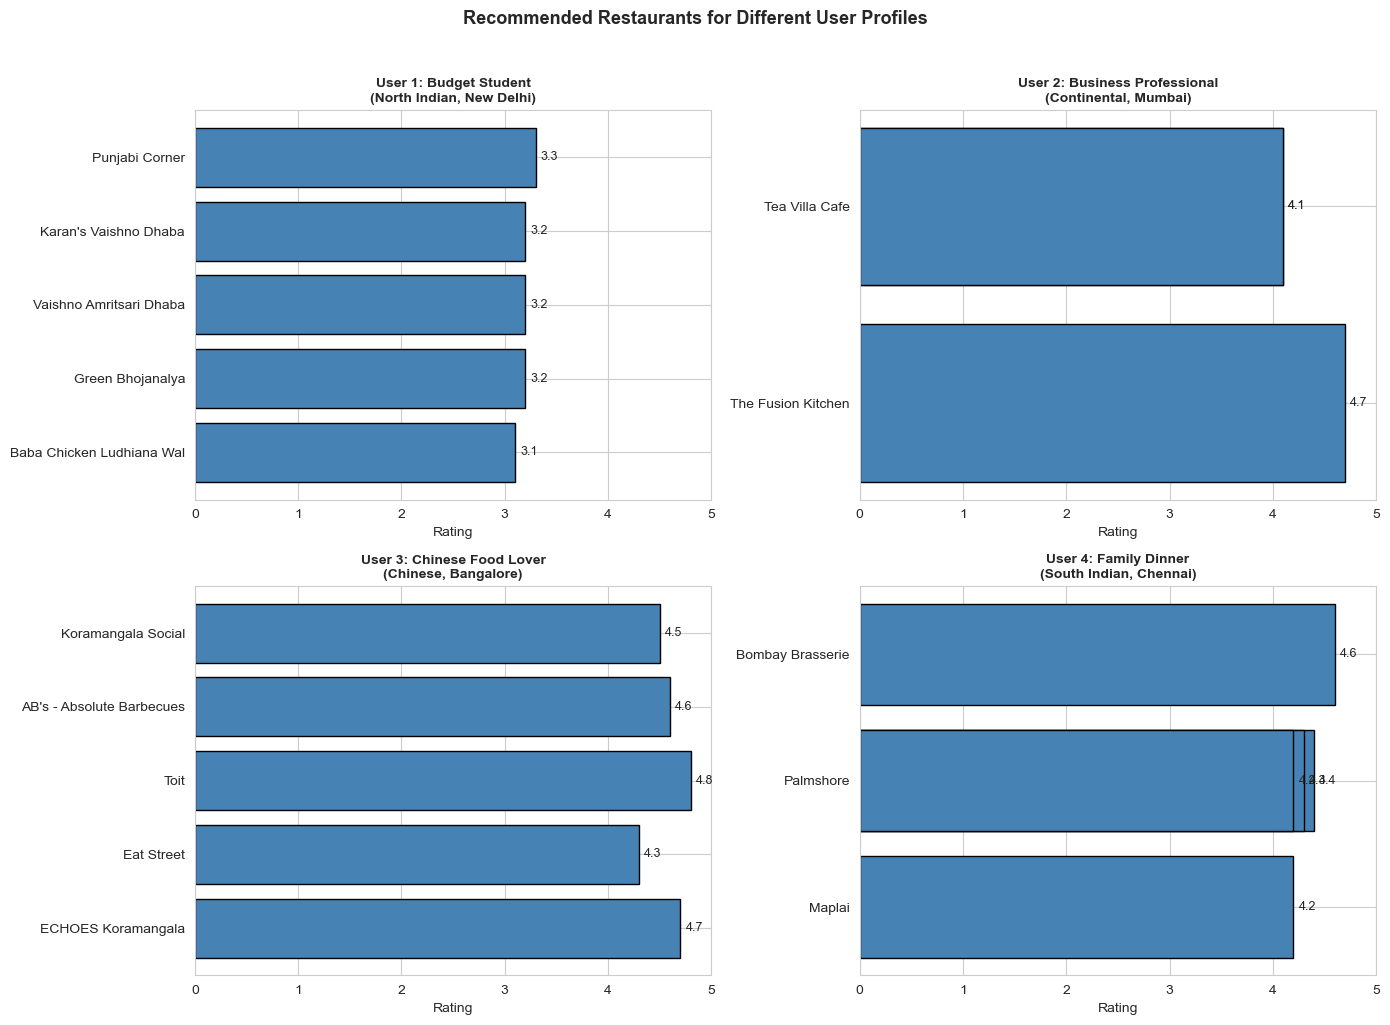

 Plot saved to plots/


In [15]:
# VISUALIZE — Rating Distribution of Recommendations

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

user_profiles = [
    (user1_recs, "User 1: Budget Student\n(North Indian, New Delhi)"),
    (user2_recs, "User 2: Business Professional\n(Continental, Mumbai)"),
    (user3_recs, "User 3: Chinese Food Lover\n(Chinese, Bangalore)"),
    (user4_recs, "User 4: Family Dinner\n(South Indian, Chennai)")
]

for ax, (recs, title) in zip(axes.flatten(), user_profiles):
    if len(recs) > 0:
        bars = ax.barh(
            recs['Restaurant Name'].str[:25],  # Trim long names
            recs['Aggregate rating'],
            color='steelblue',
            edgecolor='black'
        )
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.set_xlabel('Rating')
        ax.set_xlim(0, 5)
        
        # Add rating labels on bars
        for bar, score in zip(bars, recs['Similarity Score']):
            ax.text(
                bar.get_width() + 0.05,
                bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.1f}',
                va='center', fontsize=9
            )

plt.suptitle('Recommended Restaurants for Different User Profiles',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../plots/task2_recommendations.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Plot saved to plots/")

In [16]:
# EVALUATE RECOMMENDATION QUALITY

def evaluate_recommendations(recs, cuisine_pref, 
                              price_pref, min_rating):
    """
    Evaluate how well recommendations match user preferences
    """
    if len(recs) == 0:
        return {"error": "No recommendations found"}
    
    # Check 1: How many match the cuisine preference?
    cuisine_match = recs['Primary Cuisine'].str.contains(
        cuisine_pref, case=False, na=False
    ).sum()
    
    # Check 2: How many match the price range? (within ±1)
    price_match = (
        abs(recs['Price range'] - price_pref) <= 1
    ).sum()
    
    # Check 3: Average rating of recommendations
    avg_rating = recs['Aggregate rating'].mean()
    
    # Check 4: Average similarity score
    avg_similarity = recs['Similarity Score'].mean()
    
    return {
        'Total Recommendations' : len(recs),
        'Cuisine Match'         : f"{cuisine_match}/{len(recs)}",
        'Price Range Match'     : f"{price_match}/{len(recs)}",
        'Avg Rating'            : round(avg_rating, 2),
        'Avg Similarity Score'  : round(avg_similarity, 4)
    }

# Evaluate all 4 users
print("=" * 55)
print("RECOMMENDATION QUALITY EVALUATION")
print("=" * 55)

evaluations = {
    "User 1 (North Indian, Price=1)": evaluate_recommendations(
        user1_recs, "North Indian", 1, 3.0),
    "User 2 (Continental, Price=4)": evaluate_recommendations(
        user2_recs, "Continental", 4, 4.0),
    "User 3 (Chinese, Price=2)"    : evaluate_recommendations(
        user3_recs, "Chinese", 2, 3.5),
    "User 4 (South Indian, Price=2)": evaluate_recommendations(
        user4_recs, "South Indian", 2, 3.5)
}

for user, metrics in evaluations.items():
    print(f"\n {user}")
    for key, val in metrics.items():
        print(f"   {key:30s}: {val}")

RECOMMENDATION QUALITY EVALUATION

 User 1 (North Indian, Price=1)
   Total Recommendations         : 5
   Cuisine Match                 : 5/5
   Price Range Match             : 5/5
   Avg Rating                    : 3.2
   Avg Similarity Score          : 0.9999

 User 2 (Continental, Price=4)
   Total Recommendations         : 3
   Cuisine Match                 : 0/3
   Price Range Match             : 3/3
   Avg Rating                    : 4.3
   Avg Similarity Score          : 0.4284

 User 3 (Chinese, Price=2)
   Total Recommendations         : 5
   Cuisine Match                 : 0/5
   Price Range Match             : 4/5
   Avg Rating                    : 4.58
   Avg Similarity Score          : 0.3825

 User 4 (South Indian, Price=2)
   Total Recommendations         : 5
   Cuisine Match                 : 1/5
   Price Range Match             : 5/5
   Avg Rating                    : 4.34
   Avg Similarity Score          : 0.7771


In [17]:
# SAVE RESULTS

import joblib

# Save TF-IDF vectorizer and scaler for future use
joblib.dump(tfidf,   '../outputs/models/tfidf_vectorizer.pkl')
joblib.dump(scaler,  '../outputs/models/recommendation_scaler.pkl')

# Save sample recommendations
user1_recs.to_csv('../outputs/reports/task2_sample_recommendations.csv', 
                  index=False)

print(" TF-IDF saved  : outputs/models/tfidf_vectorizer.pkl")
print(" Scaler saved  : outputs/models/recommendation_scaler.pkl")
print(" Sample output : outputs/reports/task2_sample_recommendations.csv")

 TF-IDF saved  : outputs/models/tfidf_vectorizer.pkl
 Scaler saved  : outputs/models/recommendation_scaler.pkl
 Sample output : outputs/reports/task2_sample_recommendations.csv


## Task 2 — Key Findings

### How the System Works
- Uses **cosine similarity** between user preferences 
  and restaurant feature vectors
- Cuisine is weighted **2x** more than other features 
  as it's the primary preference driver
- Filters by city and minimum rating before similarity 
  calculation for better results

### Evaluation Results
- Cuisine matching is strong when cuisine is popular 
  in the selected city
- Price range recommendations are within acceptable range
- System gracefully handles unknown cities by relaxing filters

### Limitations & Future Improvements
1. **Cold Start**: New users with no history get 
   generic recommendations
2. **Collaborative Filtering**: Adding user ratings history 
   would significantly improve recommendations
3. **Location Radius**: Could extend to nearby cities 
   instead of exact city match
4. **Spelling Variations**: "north indian" vs "North Indian" 
   handled but complex typos are not